In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 


In [12]:
df = pd.read_csv("../bench_results_cache/8-nbeap.csv")
df.head()

,op,size,cpu_time,cpu_time_2withoutBubbleUp,cpu_time_3withBubbleUp
0,Construct,256.0,8.11326,7.29043,7.34577
1,Construct,1024.0,26.45150,24.29010,24.22940
2,Construct,4096.0,25.96920,23.70710,23.96710
3,Construct,16384.0,17.40450,16.28660,15.85260
4,Construct,65536.0,16.43430,15.64240,15.22820


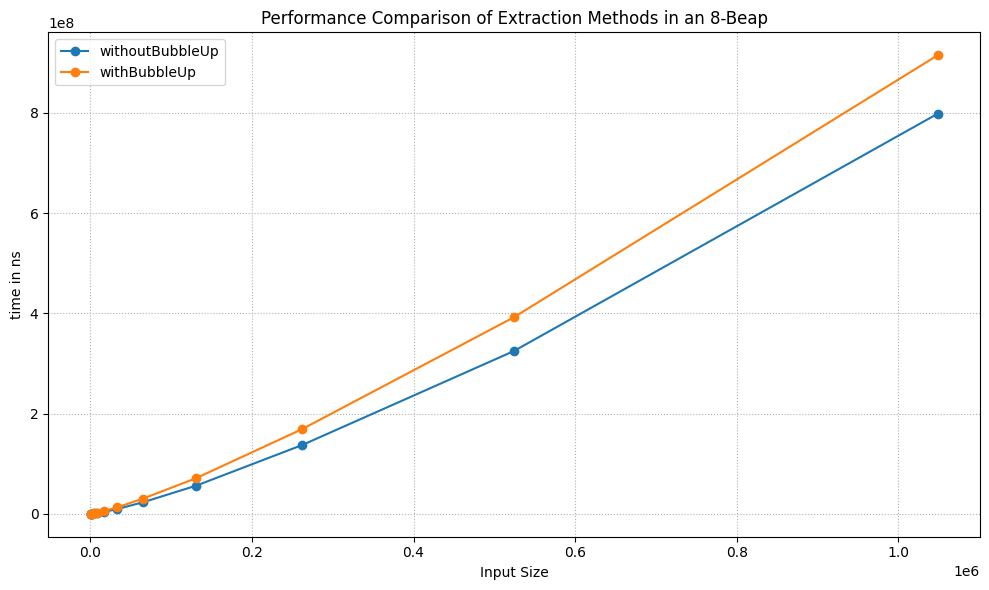

In [11]:
otherCols = ["op", "size"]
labelMap = {
    "cpu_time_2withoutBubbleUp" : "withoutBubbleUp", 
    "cpu_time_3withBubbleUp" : "withBubbleUp"
            }
colsToPlot = ["cpu_time_2withoutBubbleUp", "cpu_time_3withBubbleUp"]
df_extract = df[df["op"] == "Extract"] 
df_extract = df_extract.sort_values("size")

plt.figure(figsize=(10,6))
plt.title(f"Performance Comparison of Extraction Methods in an 8-Beap")
plt.xlabel("Input Size")
plt.ylabel("time in ns")
# plt.xscale("log", base=2)
# plt.yscale("log", base=2)
# plt.ylim(bottom=0)

x = df_extract["size"].to_numpy()

for col in colsToPlot:
    y = df_extract[col].to_numpy()
    plt.plot(x, y, marker="o", label=labelMap[col])
    #print(y)

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_csv("../bench_results_cache2/8-nbeap.csv")
df.head()

,op,size,cpu_time2withoutBubbleUp,stat,cpu_time_3withBubbleUp,cpu_time_4withBubbleUp
0,Construct,256.0,8.523730,mean,8.31859,8.250830
1,Construct,256.0,8.316590,median,8.29257,8.230650
2,Construct,256.0,0.586450,stddev,8.20993,0.057255
3,Construct,256.0,0.068802,cv,8.31009,0.006939
4,Construct,256.0,9.028400,p90,8.33303,8.320030


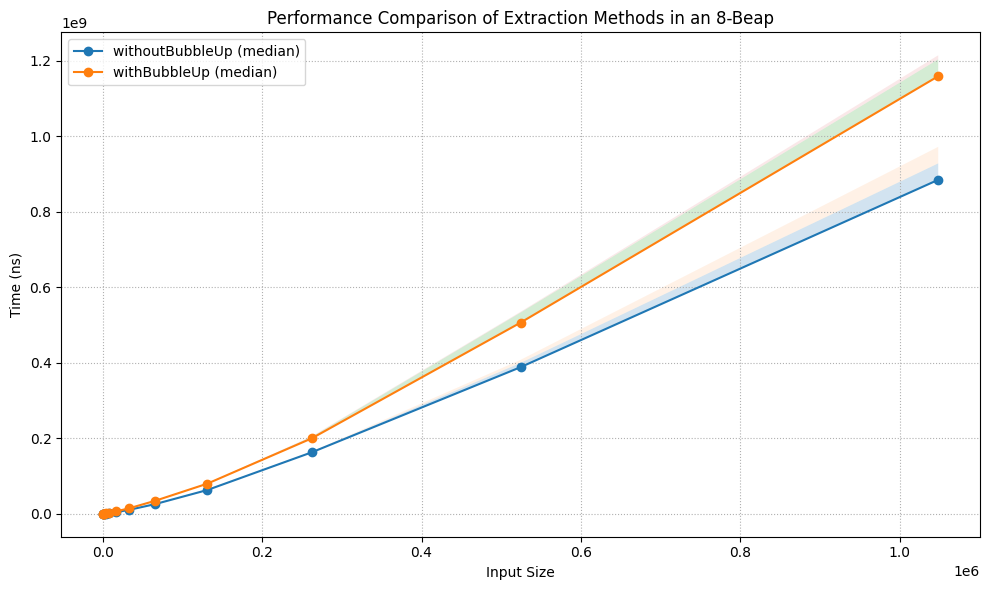

In [ ]:
labelMap = {
    "cpu_time2withoutBubbleUp": "withoutBubbleUp",
    "cpu_time_4withBubbleUp": "withBubbleUp"
}

baseCols = ["cpu_time2withoutBubbleUp", "cpu_time_4withBubbleUp"]

df_extract = df[df["op"] == "Extract"].copy()
df_extract["size"] = pd.to_numeric(df_extract["size"])

# Pivot so each stat becomes a suffix-like column per cpu_time series
df_plot = df_extract.pivot(index="size", columns="stat", values=baseCols)

# Sort by input size
df_plot = df_plot.sort_index()

plt.figure(figsize=(10, 6))
plt.title("Performance Comparison of Extraction Methods in an 8-Beap")
plt.xlabel("Input Size")
plt.ylabel("Time (ns)")
# plt.xscale("log", base=2)
# plt.yscale("log", base=10)

x = df_plot.index.to_numpy()

for base in baseCols:
    y_median = df_plot[(base, "median")].to_numpy()
    y_p90 = df_plot[(base, "p90")].to_numpy()
    y_p99 = df_plot[(base, "p99")].to_numpy()

    plt.plot(x, y_median, marker="o", label=f"{labelMap[base]} (median)")
    plt.fill_between(x, y_median, y_p90, alpha=0.20)
    plt.fill_between(x, y_p90, y_p99, alpha=0.10)

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()

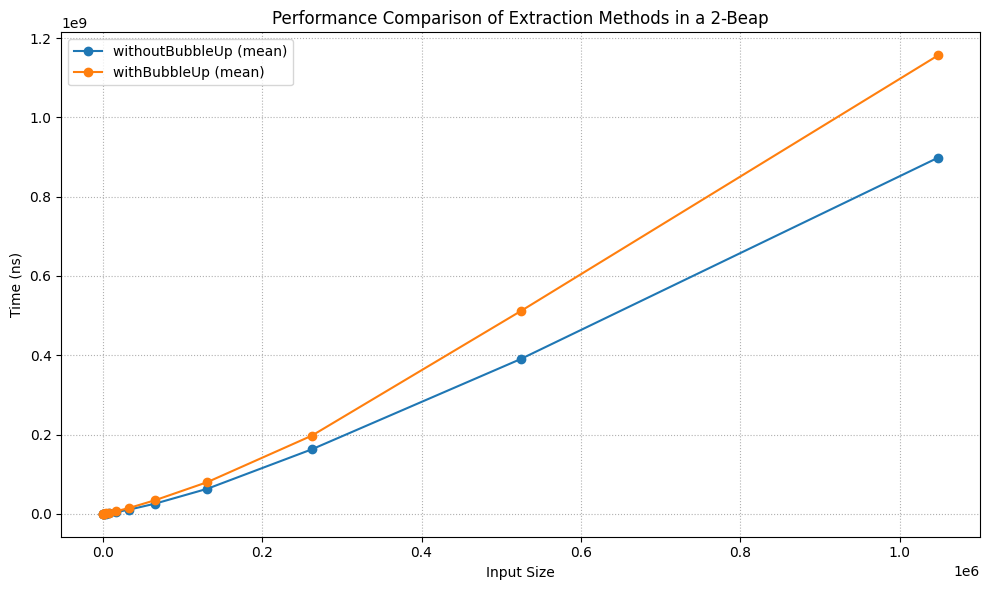

In [ ]:

labelMap = {
    "cpu_time2withoutBubbleUp": "withoutBubbleUp",
    "cpu_time_4withBubbleUp": "withBubbleUp"
}

baseCols = ["cpu_time2withoutBubbleUp", "cpu_time_4withBubbleUp"]

df_extract = df[df["op"] == "Extract"].copy()
df_extract["size"] = pd.to_numeric(df_extract["size"])

df_plot = df_extract.pivot(index="size", columns="stat", values=baseCols)
df_plot = df_plot.sort_index()

plt.figure(figsize=(10, 6))
plt.title("Performance Comparison of Extraction Methods in a 2-Beap")
plt.xlabel("Input Size")
plt.ylabel("Time (ns)")
# plt.xscale("log", base=2)
# plt.yscale("log", base=10)

x = df_plot.index.to_numpy()

for base in baseCols:
    y_mean = df_plot[(base, "median")].to_numpy()
    plt.plot(x, y_mean, marker="o", label=f"{labelMap[base]} (mean)")

plt.grid(True, which="both", linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()